In [1]:
import numpy as np
import pandas as pd

from sklearn.decomposition import PCA

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
from composition_stats import clr


%matplotlib inline
%config InlineBackend.figure_format = 'retina'
matplotlib.rc('font',**{'family':'Avenir', 'size': 20})
plt.rcParams['pdf.fonttype'] = 42

## Loading in DF

This code loads in the dataframe you are using. This dataframe has been pre-treated in the test_train_split.ipynb file. It includes synthetic and real data, predesignated as test or train.

In [2]:
input_file = 'test_train_df.csv'
alkanes = ["C25", 'C27', 'C29', 'C31', 'C33', 'C35']

In [3]:
min_df = pd.read_csv(input_file).iloc[:, 2:]
min_df

,source,ID,species,loc_sure,lon,lat,altitude,family,subfam,dom,...,notes,wg,photo_subfam,clr1,clr2,clr3,clr4,clr5,clr6,split
0,This Study,KU819,Eragrostis sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,Grassy,C4 Aristidoideae,-1.556634,-0.330891,0.049928,0.984478,1.601485,-0.748366,train
1,This Study,KU821,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,Grassy,C4 Aristidoideae,-0.599286,0.208202,0.720406,1.342197,0.506745,-2.178264,train
2,This Study,KU823,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,Grassy,C4 Aristidoideae,-0.843636,0.178409,0.927436,1.497981,0.614922,-2.375112,train
3,This Study,KU824,Aristida mutabilis (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,Grassy,C4 Aristidoideae,0.204837,0.545220,0.345018,1.305671,-0.052425,-2.348321,train
4,This Study,KU832,Aristida adscensionis (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,NaN,Grassy,C4 Aristidoideae,-0.387803,0.707822,1.393839,1.981416,0.156029,-3.851304,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Grassy,NaN,-1.014830,-0.808296,-0.166907,1.217938,1.082994,-0.310898,synthetic_test
941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Grassy,NaN,-1.577296,0.051581,0.944968,2.312541,0.976251,-2.708045,synthetic_test
942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Grassy,NaN,-1.000960,-0.545139,0.016881,1.357799,0.909765,-0.738345,synthetic_test
943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,Grassy,NaN,-0.712372,-0.485431,-0.030177,0.824862,0.841054,-0.437936,synthetic_test


In [4]:
train_df = min_df[min_df['split'] == 'train']
test_df = min_df[min_df['split'] == 'test']

In [5]:
# Rows where BOTH lon and source are missing
mask = min_df["lon"].isna() & min_df["source"].isna()

print("Rows with missing lon AND missing source:", mask.sum())

min_df.loc[mask, ["source", "species", "lon", "lat"]]

Rows with missing lon AND missing source: 320


,source,species,lon,lat
493,NaN,NaN,NaN,NaN
494,NaN,NaN,NaN,NaN
495,NaN,NaN,NaN,NaN
496,NaN,NaN,NaN,NaN
497,NaN,NaN,NaN,NaN
...,...,...,...,...
940,NaN,NaN,NaN,NaN
941,NaN,NaN,NaN,NaN
942,NaN,NaN,NaN,NaN
943,NaN,NaN,NaN,NaN


# Prepping DF for ML

Below, I convert the woody or grassy designation into a number code (0 or 1) to be used in data treatement further down, and create cat_lab which tracks the entries in the min_df.wg column.

In [6]:
code = pd.Categorical(min_df['wg']).codes
cat_lab = pd.Categorical(min_df['wg'])

Below, you could edit down your min_df dataframe to only contain certain data classes, e.g. no synthetic data.

In [7]:
#min_df=min_df[(min_df['split'] == 'train') | (min_df['split'] == 'test')]
#min_df.split

Below, I use the pre-ordained classifications in test_train_df to pull out the training and testing data for both the only real data and the synthetic + real datasets.

In [8]:
targets = ['clr1', 'clr2', 'clr3', 'clr4', 'clr5', 'clr6']

train_data_x_df = min_df[targets][min_df['split'] == 'train']
train_data_y = min_df['wg'][min_df['split'] == 'train']
train_data_x = train_data_x_df.values

train_data_x_res_df = min_df[targets][(min_df['split'] == 'train') | (min_df['split'] == 'synthetic_train')]
train_data_y_res = min_df['wg'][(min_df['split'] == 'train') | (min_df['split'] == 'synthetic_train')]
train_data_x_res = train_data_x_res_df.values

test_data_x_df = min_df[targets][min_df['split'] == 'test']
test_data_y = min_df['wg'][min_df['split'] == 'test']
test_data_x = test_data_x_df

test_data_x_res_df = min_df[targets][(min_df['split'] == 'test') | (min_df['split'] == 'synthetic_test')]
test_data_y_res = min_df['wg'][(min_df['split'] == 'test') | (min_df['split'] == 'synthetic_test')]
test_data_x_res = test_data_x_res_df


## PCA

In [9]:
wt = min_df[alkanes].fillna(0).to_numpy()
wt_scale = clr(wt)

pca_for_wt = PCA(n_components = 4)
pca_for_z = PCA(n_components = 4)
wt_pca = pca_for_wt.fit_transform(wt)

wt_z_pca = pca_for_z.fit_transform(wt_scale)


def myplot(coeff,labels=None):
    n = coeff.shape[0]
    for i in range(n):
        plt.arrow(0, 0, coeff[i,0], coeff[i,1],color = 'r',alpha = 0.5)
        if labels is None:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, "Var"+str(i+1), color = 'g', ha = 'center', va = 'center')
        else:
            plt.text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'g', ha = 'center', va = 'center')
            

lab = min_df['wg'].unique()
lab

array(['Grassy', 'Woody'], dtype=object)

In [26]:
len(wt)

945

In [10]:
print('Explained variation per principal component: {}'.format(pca_for_wt.explained_variance_ratio_))

Explained variation per principal component: [0.54667848 0.27098567 0.12205377 0.03569044]


In [11]:
sum(pca_for_z.explained_variance_ratio_)

0.9765239320494458

In [12]:
print('Explained variation per principal component: {}'.format(pca_for_z.explained_variance_ratio_))

Explained variation per principal component: [0.45237566 0.36273179 0.10772406 0.05369243]


In [13]:
pftz = range(1, len(lab))
pftz

range(1, 2)

In [14]:
pca_df = pd.DataFrame(wt_z_pca, columns = ['PC1','PC2','PC3','PC4'])
pca_df

,PC1,PC2,PC3,PC4
0,-3.114991,-0.385318,0.064536,-0.681212
1,-1.248123,0.743874,-0.185808,-0.272843
2,-0.998064,0.417221,-0.202408,-0.222175
3,-1.077621,1.733391,-0.315697,-0.314383
4,0.703107,0.819619,-0.657441,-0.153148
...,...,...,...,...
940,-3.547320,0.143325,0.078121,0.039341
941,-0.649458,-0.655231,-0.332566,-0.059543
942,-2.978076,0.205276,0.076484,-0.005714
943,-3.324470,0.680112,0.184550,-0.194272


In [15]:
min_df[['PC1','PC2','PC3', 'PC4']]= pca_df[['PC1','PC2','PC3', 'PC4']]
min_df

,source,ID,species,loc_sure,lon,lat,altitude,family,subfam,dom,...,clr2,clr3,clr4,clr5,clr6,split,PC1,PC2,PC3,PC4
0,This Study,KU819,Eragrostis sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,-0.330891,0.049928,0.984478,1.601485,-0.748366,train,-3.114991,-0.385318,0.064536,-0.681212
1,This Study,KU821,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.208202,0.720406,1.342197,0.506745,-2.178264,train,-1.248123,0.743874,-0.185808,-0.272843
2,This Study,KU823,Aristida sp.,Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.178409,0.927436,1.497981,0.614922,-2.375112,train,-0.998064,0.417221,-0.202408,-0.222175
3,This Study,KU824,Aristida mutabilis (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.545220,0.345018,1.305671,-0.052425,-2.348321,train,-1.077621,1.733391,-0.315697,-0.314383
4,This Study,KU832,Aristida adscensionis (?),Y,7.951042,16.990325,NaN,Poaceae,Aristidoideae,A,...,0.707822,1.393839,1.981416,0.156029,-3.851304,train,0.703107,0.819619,-0.657441,-0.153148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
940,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.808296,-0.166907,1.217938,1.082994,-0.310898,synthetic_test,-3.547320,0.143325,0.078121,0.039341
941,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.051581,0.944968,2.312541,0.976251,-2.708045,synthetic_test,-0.649458,-0.655231,-0.332566,-0.059543
942,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.545139,0.016881,1.357799,0.909765,-0.738345,synthetic_test,-2.978076,0.205276,0.076484,-0.005714
943,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.485431,-0.030177,0.824862,0.841054,-0.437936,synthetic_test,-3.324470,0.680112,0.184550,-0.194272


In [16]:
tab = plt.get_cmap('tab20')
cNorm  = mcolors.Normalize(vmin=0, vmax=len(lab))
scalarMap = mcm.ScalarMappable(norm=cNorm, cmap=tab)

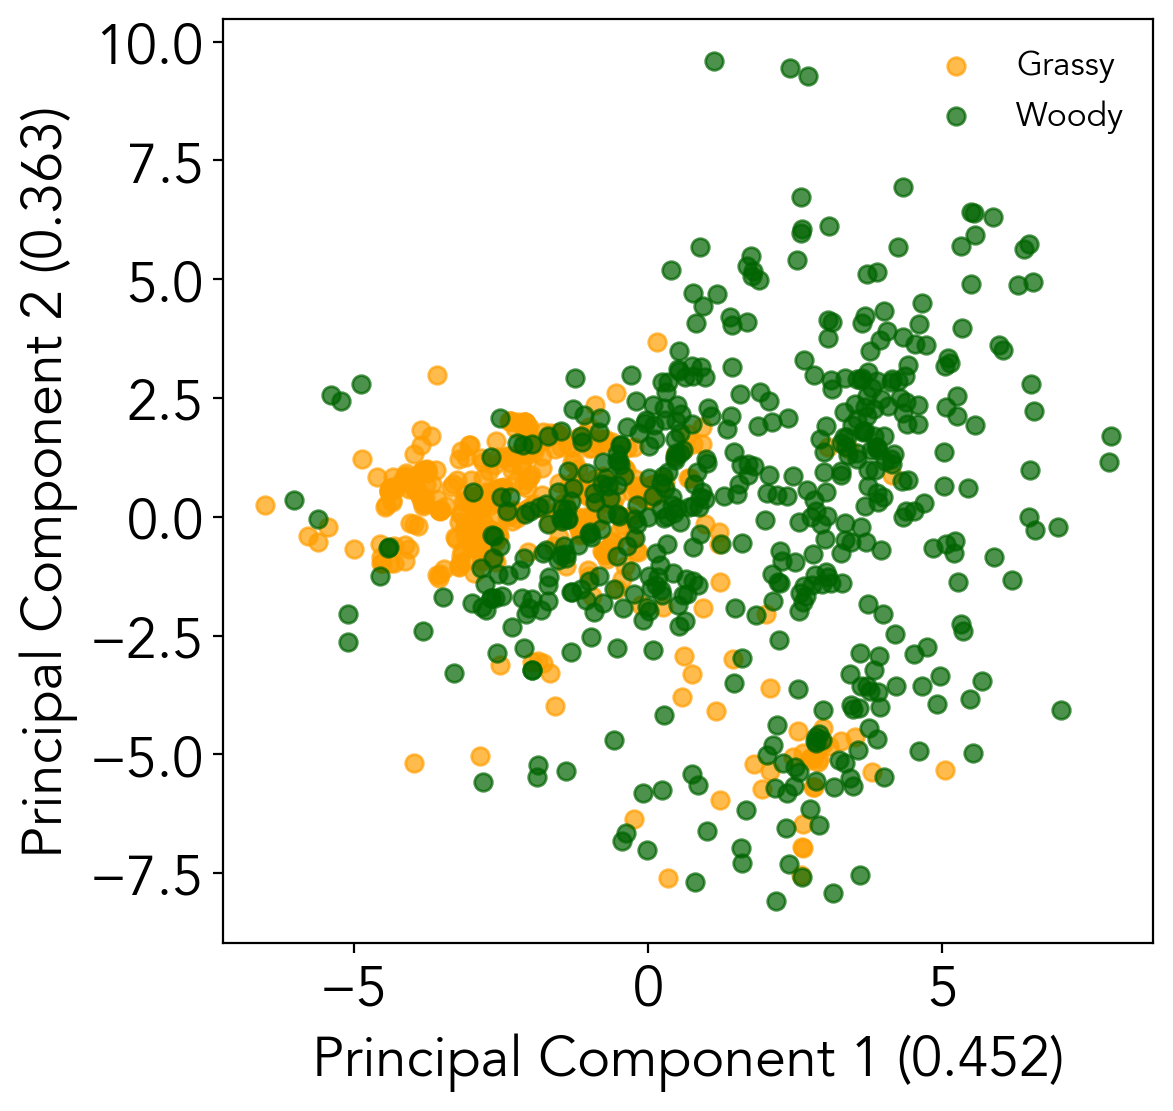

In [17]:
# Define consistent colors for both figures
color_map = {'Woody': 'darkgreen', 'Grassy': '#FF9E00'}

fig, ax = plt.subplots(figsize=(6, 6))

for label in lab:  # assuming lab = ['Woody', 'Grassy']
    indx = min_df['wg'] == label
    ax.scatter(
        wt_z_pca[indx][:, 0],
        wt_z_pca[indx][:, 1],
        s=40,
        color=color_map[label],  # use fixed color here
        lw=1,
        label=label,
        alpha = 0.7
    )

ax.legend(prop={'size': 12}, frameon=False)
ax.set_xlabel(f'Principal Component 1 ({np.around(pca_for_z.explained_variance_ratio_[0], 3)})')
ax.set_ylabel(f'Principal Component 2 ({np.around(pca_for_z.explained_variance_ratio_[1], 3)})')

plt.savefig('PCA_vis.png', dpi=300, transparent=True, bbox_inches='tight', pad_inches=0.025)
plt.show()

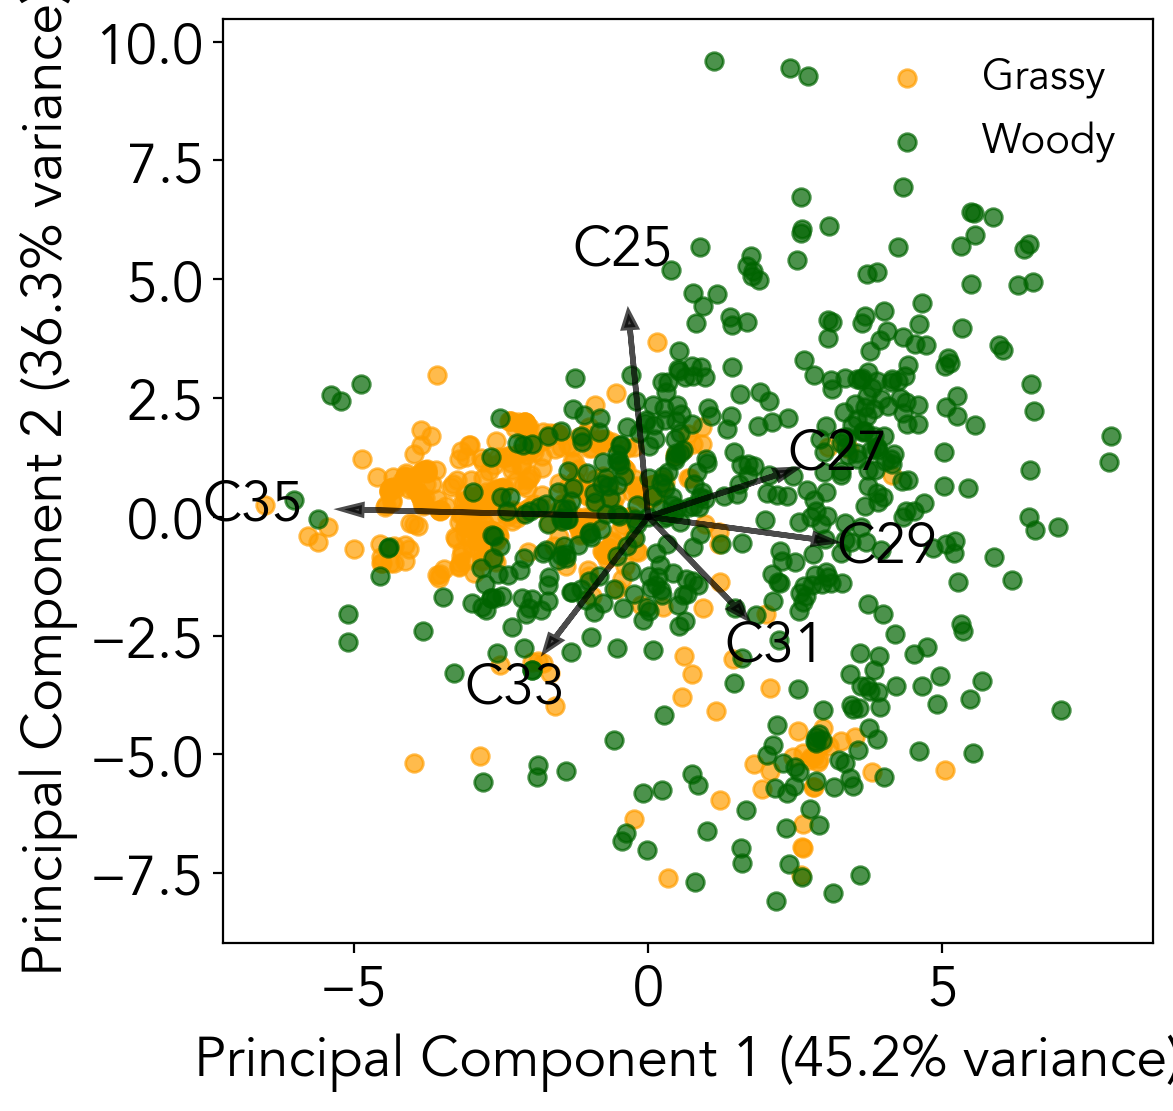

In [18]:
# Define consistent colors for both figures
color_map = {'Woody': 'darkgreen', 'Grassy': '#FF9E00'}
#alkanes = ['C25', 'C27', 'C29', 'C31', 'C33', 'C35']  # feature names

fig, ax = plt.subplots(figsize=(6, 6))

# === Scatter plot of samples ===
for label in lab:  # assuming lab = ['Woody', 'Grassy']
    indx = min_df['wg'] == label
    ax.scatter(
        wt_z_pca[indx][:, 0],
        wt_z_pca[indx][:, 1],
        s=40,
        color=color_map[label],
        lw=1,
        label=label,
        alpha=0.7
    )

# === Add PCA loading vectors (biplot arrows) ===
coeff = pca_for_z.components_.T  # loadings
n = coeff.shape[0]               # number of features

# Scale arrows to fit nicely in plot
scalex = 1.0 / (wt_z_pca[:, 0].max() - wt_z_pca[:, 0].min())
scaley = 1.0 / (wt_z_pca[:, 1].max() - wt_z_pca[:, 1].min())

for i in range(n):
    ax.arrow(
        0, 0,
        coeff[i, 0] * scalex * 100,  # tweak the 1.2 multiplier if needed
        coeff[i, 1] * scaley * 100,
        color='black',
        alpha=0.7,
        lw=2,
        head_width=0.2,
        length_includes_head=True
    )
    ax.text(
        coeff[i, 0] * scalex * 130,
        coeff[i, 1] * scaley * 130,
        alkanes[i],
        color='black',
        ha='center',
        va='center',
        fontsize=20
    )

# === Aesthetics ===
ax.legend(prop={'size': 15}, frameon=False)
ax.set_xlabel(f'Principal Component 1 ({pca_for_z.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'Principal Component 2 ({pca_for_z.explained_variance_ratio_[1]*100:.1f}% variance)')
#ax.set_title('PCA of n-Alkane Distributions', fontsize=13)

# Save figure
plt.savefig('PCA_vis_with_vectors.png', dpi=300, transparent=True, bbox_inches='tight', pad_inches=0.025)
plt.show()

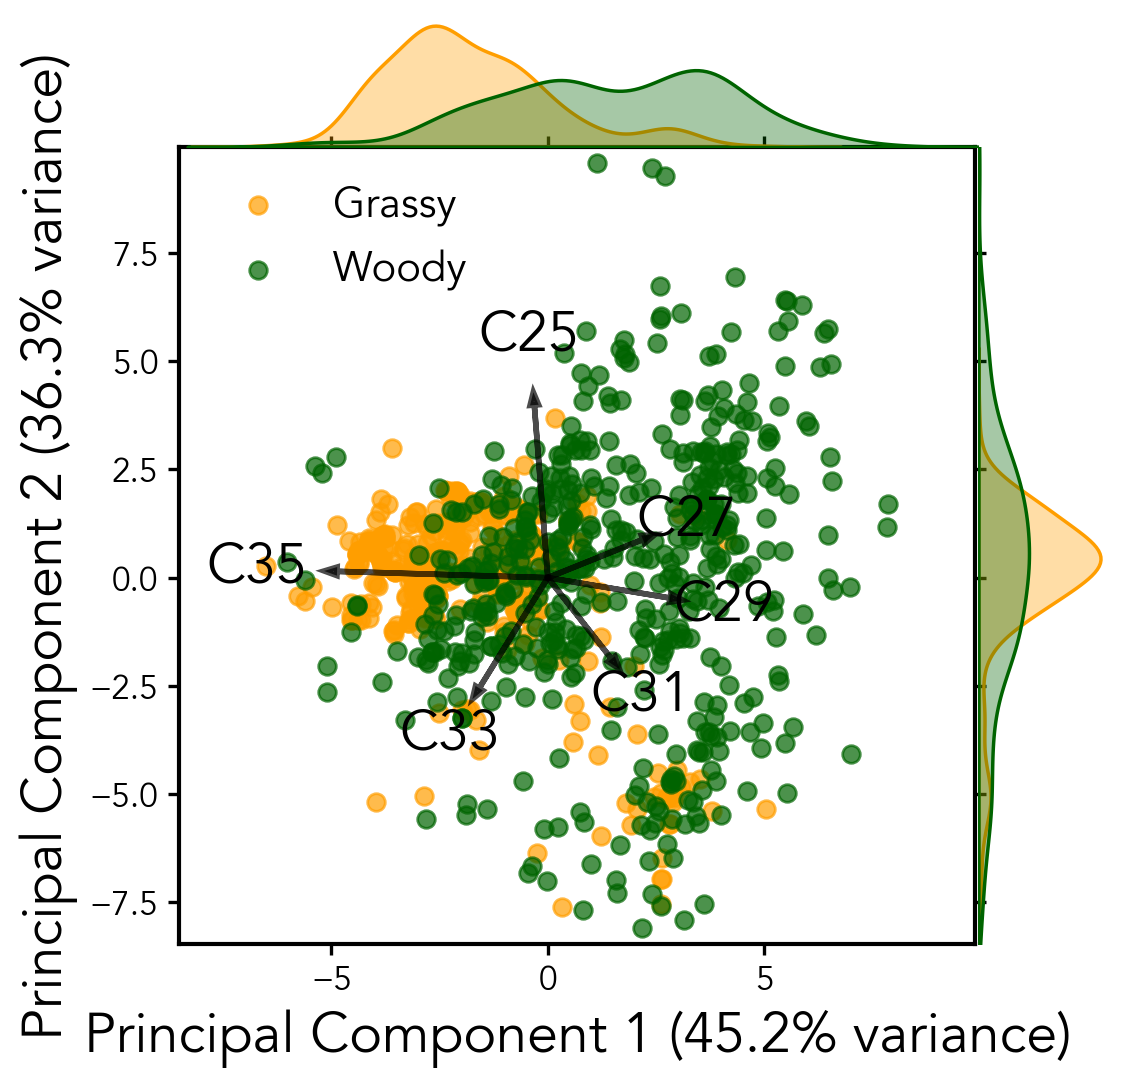

In [ ]:
# --- Imports ---
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import numpy as np

# ----------------------------------------------------------------------------------
# Assumes the following exist:
# - min_df: DataFrame with a column 'wg' containing 'Woody'/'Grassy'
# - lab: list like ['Woody', 'Grassy']
# - wt_z_pca: numpy array (n_samples, 2) for PC1 and PC2
# - pca_for_z: fitted PCA object with .components_ and .explained_variance_ratio_
# ----------------------------------------------------------------------------------

# === Styling / colors ===
color_map = {'Woody': 'darkgreen', 'Grassy': '#FF9E00'}

# --- Figure layout: main scatter + marginal PDFs ---
fig = plt.figure(figsize=(6, 6))
gs = GridSpec(
    2, 2,
    width_ratios=[5, 0.8],   # small right panel
    height_ratios=[0.8, 5],  # small top panel
    wspace=0.001, hspace=0.001  # flush alignment
)

ax_scatter = fig.add_subplot(gs[1, 0])
ax_top     = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_right   = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# === Scatter plot of samples ===
for label in lab:
    indx = (min_df['wg'] == label)
    ax_scatter.scatter(
        wt_z_pca[indx][:, 0],
        wt_z_pca[indx][:, 1],
        s=40,
        color=color_map[label],
        lw=1,
        label=label,
        alpha=0.7
    )

# === Add PCA loading vectors (biplot arrows) ===
coeff = pca_for_z.components_.T
n = coeff.shape[0]

pc1_range = wt_z_pca[:, 0].max() - wt_z_pca[:, 0].min()
pc2_range = wt_z_pca[:, 1].max() - wt_z_pca[:, 1].min()
scalex = 1.0 / pc1_range if pc1_range != 0 else 1.0
scaley = 1.0 / pc2_range if pc2_range != 0 else 1.0

if len(alkanes) != n:
    alkanes = [f"Var{i+1}" for i in range(n)]

for i in range(n):
    ax_scatter.arrow(
        0, 0,
        coeff[i, 0] * scalex * 100,
        coeff[i, 1] * scaley * 100,
        color='black',
        alpha=0.7,
        lw=2,
        head_width=0.2,
        length_includes_head=True
    )
    ax_scatter.text(
        coeff[i, 0] * scalex * 130,
        coeff[i, 1] * scaley * 130,
        alkanes[i],
        color='black',
        ha='center',
        va='center',
        fontsize=20
    )

# === Make PCA panel a true square with a full box frame ===
x0, x1 = wt_z_pca[:, 0].min(), wt_z_pca[:, 0].max()
y0, y1 = wt_z_pca[:, 1].min(), wt_z_pca[:, 1].max()
xmid, ymid = (x0 + x1) / 2.0, (y0 + y1) / 2.0
half = max(x1 - x0, y1 - y0) * 0.52   # adds ~4% padding

ax_scatter.set_xlim(xmid - half, xmid + half)
ax_scatter.set_ylim(ymid - half, ymid + half)
ax_scatter.set_aspect('equal', adjustable='box')

# === Customize PCA ticks ===

# 1️⃣ Keep only bottom + left ticks visible
ax_scatter.tick_params(
    axis='both',
    which='both',
    top=False, right=False,   # hide top/right ticks
    bottom=True, left=True,   # keep bottom/left ticks
    direction='out',
    length=5, width=1.2,
    labelsize=12
)

# 2️⃣ Optionally, set specific tick locations
# (replace with whatever range fits your PCA scores)


# 3️⃣ Optional: make the tick labels a bit bolder for readability
ax_scatter.tick_params(labelsize=12)
for label in ax_scatter.get_xticklabels() + ax_scatter.get_yticklabels():
    label.set_fontweight('medium')

# Make all spines visible (full square)
for side in ['left', 'right', 'top', 'bottom']:
    ax_scatter.spines[side].set_visible(True)
    ax_scatter.spines[side].set_linewidth(1.5)
ax_scatter.tick_params(direction='out', length=4, width=1.2, top=True, right=True)

# === Marginal PDFs (class-conditional KDEs) ===
for label in lab:
    indx = (min_df['wg'] == label)
    xvals = wt_z_pca[indx][:, 0]
    yvals = wt_z_pca[indx][:, 1]

    sns.kdeplot(
        x=xvals, ax=ax_top, fill=True,
        alpha=0.35, linewidth=1.25, color=color_map[label]
    )
    sns.kdeplot(
        y=yvals, ax=ax_right, fill=True,
        alpha=0.35, linewidth=1.25, color=color_map[label]
    )

# Hide all axes for marginal PDFs
for ax in [ax_top, ax_right]:
    ax.axis('off')

# === Sync limits so PDFs align exactly with PCA box ===
ax_top.set_xlim(ax_scatter.get_xlim())
ax_right.set_ylim(ax_scatter.get_ylim())

# === Labels, legend, etc. ===
ax_scatter.legend(prop={'size': 15}, frameon=False)
ax_scatter.set_xlabel(f'Principal Component 1 ({pca_for_z.explained_variance_ratio_[0]*100:.1f}% variance)')
ax_scatter.set_ylabel(f'Principal Component 2 ({pca_for_z.explained_variance_ratio_[1]*100:.1f}% variance)')

# --- Save & show ---
plt.savefig(
    'PCA_vis_with_box_and_marginal_PDFs.png',
    dpi=300, transparent=True, bbox_inches='tight', pad_inches=0.025
)
plt.show()

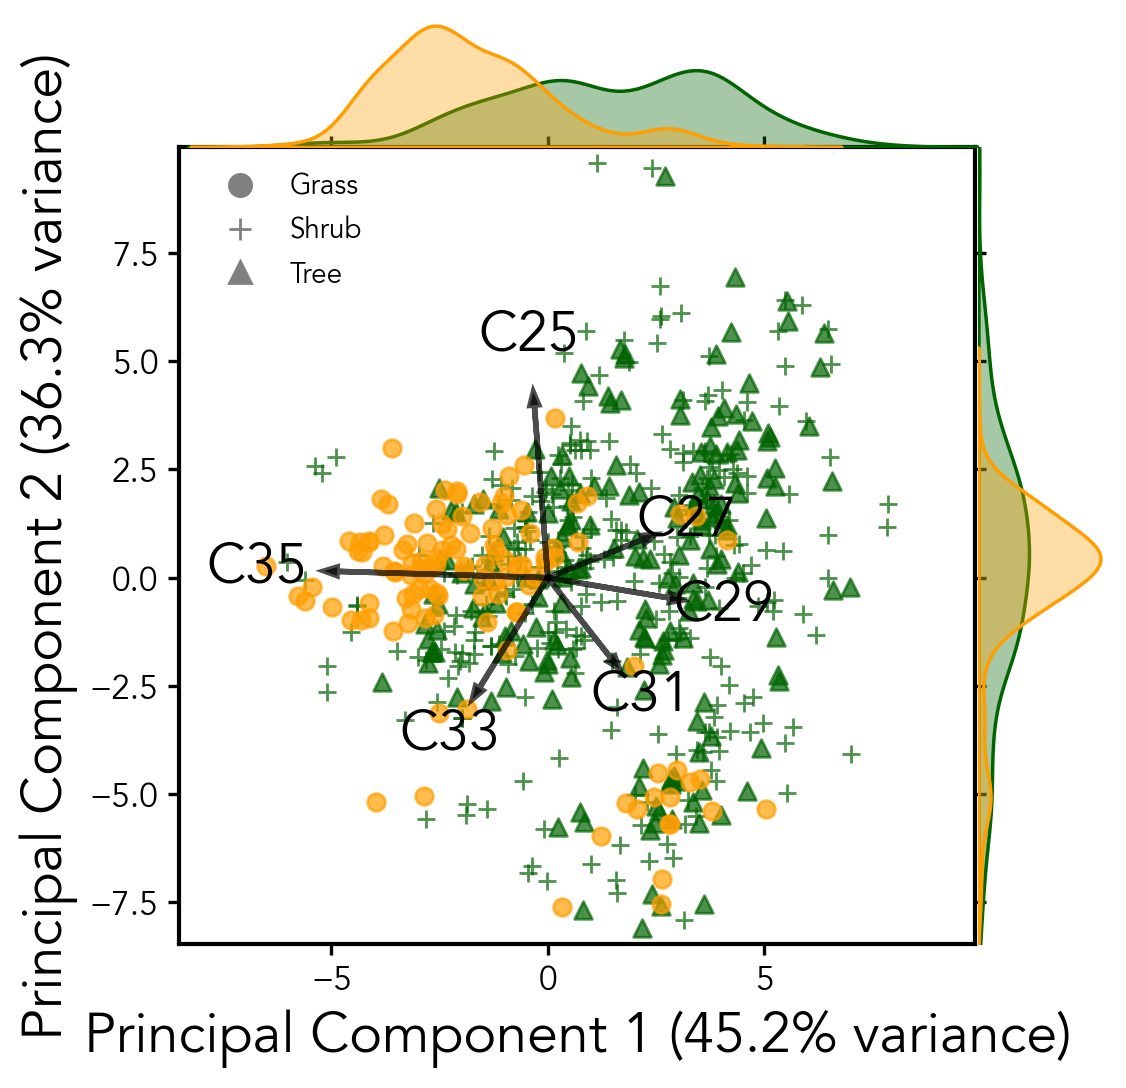

In [20]:
# --- Imports ---
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import numpy as np

# ----------------------------------------------------------------------------------
# Assumes the following exist:
# - min_df: DataFrame with columns:
#     - 'wg'  containing 'Woody'/'Grassy'   (COLOR)
#     - 'pft' containing plant functional type (SYMBOL)
# - wt_z_pca: numpy array (n_samples, 2) for PC1 and PC2
# - pca_for_z: fitted PCA object with .components_ and .explained_variance_ratio_
# ----------------------------------------------------------------------------------

# === Styling / colors (Woody vs Grassy) ===
wg_color_map = {'Woody': 'darkgreen', 'Grassy': '#FF9E00'}
wg_labels = ['Woody', 'Grassy']  # do NOT use `lab` (it can get overwritten in notebooks)

#alkanes = ['C25', 'C27', 'C29', 'C31', 'C33', 'C35']

# ===== PFT → marker dictionary (each PFT gets its own symbol) =====
pft_levels = min_df["pft"].dropna().astype(str).unique()
pft_levels = sorted(pft_levels)

marker_cycle = ['o', '+', '^']
pft_marker_map = {pft: marker_cycle[i % len(marker_cycle)] for i, pft in enumerate(pft_levels)}

# --- Figure layout: main scatter + marginal PDFs ---
fig = plt.figure(figsize=(6, 6))
gs = GridSpec(
    2, 2,
    width_ratios=[5, 0.8],    # small right panel
    height_ratios=[0.8, 5],   # small top panel
    wspace=0.001, hspace=0.001
)

ax_scatter = fig.add_subplot(gs[1, 0])
ax_top     = fig.add_subplot(gs[0, 0], sharex=ax_scatter)
ax_right   = fig.add_subplot(gs[1, 1], sharey=ax_scatter)

# === Scatter plot of samples ===
# Color = wg, marker = pft. Keep edgecolor behavior as matplotlib default (no explicit edgecolors).
for wg in wg_labels:
    for pft in pft_levels:
        mask = (min_df["wg"] == wg) & (min_df["pft"].astype(str) == str(pft))
        if mask.sum() == 0:
            continue

        ax_scatter.scatter(
            wt_z_pca[mask][:, 0],
            wt_z_pca[mask][:, 1],
            s=40,
            color=wg_color_map[wg],
            marker=pft_marker_map[pft],
            lw=1,
            alpha=0.7
        )

# === Add PCA loading vectors (biplot arrows) ===
coeff = pca_for_z.components_.T
n = coeff.shape[0]

pc1_range = wt_z_pca[:, 0].max() - wt_z_pca[:, 0].min()
pc2_range = wt_z_pca[:, 1].max() - wt_z_pca[:, 1].min()
scalex = 1.0 / pc1_range if pc1_range != 0 else 1.0
scaley = 1.0 / pc2_range if pc2_range != 0 else 1.0

if len(alkanes) != n:
    alkanes = [f"Var{i+1}" for i in range(n)]

for i in range(n):
    ax_scatter.arrow(
        0, 0,
        coeff[i, 0] * scalex * 100,
        coeff[i, 1] * scaley * 100,
        color='black',
        alpha=0.7,
        lw=2,
        head_width=0.2,
        length_includes_head=True
    )
    ax_scatter.text(
        coeff[i, 0] * scalex * 130,
        coeff[i, 1] * scaley * 130,
        alkanes[i],
        color='black',
        ha='center',
        va='center',
        fontsize=20
    )

# === Make PCA panel a true square with a full box frame ===
x0, x1 = wt_z_pca[:, 0].min(), wt_z_pca[:, 0].max()
y0, y1 = wt_z_pca[:, 1].min(), wt_z_pca[:, 1].max()
xmid, ymid = (x0 + x1) / 2.0, (y0 + y1) / 2.0
half = max(x1 - x0, y1 - y0) * 0.52   # adds ~4% padding

ax_scatter.set_xlim(xmid - half, xmid + half)
ax_scatter.set_ylim(ymid - half, ymid + half)
ax_scatter.set_aspect('equal', adjustable='box')

# === Customize PCA ticks ===
ax_scatter.tick_params(
    axis='both',
    which='both',
    top=False, right=False,
    bottom=True, left=True,
    direction='out',
    length=5, width=1.2,
    labelsize=12
)

for t in ax_scatter.get_xticklabels() + ax_scatter.get_yticklabels():
    t.set_fontweight('medium')

for side in ['left', 'right', 'top', 'bottom']:
    ax_scatter.spines[side].set_visible(True)
    ax_scatter.spines[side].set_linewidth(1.5)

ax_scatter.tick_params(direction='out', length=4, width=1.2, top=True, right=True)

# === Marginal PDFs (class-conditional KDEs; still by wg color) ===
for wg in wg_labels:
    mask = (min_df["wg"] == wg)
    xvals = wt_z_pca[mask][:, 0]
    yvals = wt_z_pca[mask][:, 1]

    sns.kdeplot(
        x=xvals, ax=ax_top, fill=True,
        alpha=0.35, linewidth=1.25, color=wg_color_map[wg]
    )
    sns.kdeplot(
        y=yvals, ax=ax_right, fill=True,
        alpha=0.35, linewidth=1.25, color=wg_color_map[wg]
    )

# Hide all axes for marginal PDFs
for ax in [ax_top, ax_right]:
    ax.axis('off')

# === Sync limits so PDFs align exactly with PCA box ===
ax_top.set_xlim(ax_scatter.get_xlim())
ax_right.set_ylim(ax_scatter.get_ylim())

# === Legend: PFT symbols ONLY (no wg legend) ===
pft_handles = [
    Line2D(
        [0], [0],
        marker=pft_marker_map[pft],
        linestyle='None',
        markersize=8,
        markerfacecolor='gray',   # show symbol only (colors are wg-driven in the plot)
        markeredgecolor='gray',
        label=str(pft)
    )
    for pft in pft_levels
]

ax_scatter.legend(
    handles=pft_handles,
    frameon=False,
    prop={'size': 10},
    title_fontsize=11,
    loc="upper left",
    bbox_to_anchor=(0.01, 1.0)
)

# === Labels ===
ax_scatter.set_xlabel(f'Principal Component 1 ({pca_for_z.explained_variance_ratio_[0]*100:.1f}% variance)')
ax_scatter.set_ylabel(f'Principal Component 2 ({pca_for_z.explained_variance_ratio_[1]*100:.1f}% variance)')

# --- Save & show ---
plt.savefig(
    'PCA_vis_with_box_and_marginal_PDFs_wgcolor_pftsymbols.png',
    dpi=300, transparent=True, bbox_inches='tight', pad_inches=0.025
)
plt.show()

In [21]:
# Marker by PFT / growth form
marker_map = {
    "shrub": "s",   # square
    "tree":  "o",   # circle
    "grass": "o",   # circle
}

In [22]:
def pca_sum_hom_influence(df, princ_plant_Df, score, coeff, labels=None):
    fig, ax = plt.subplots(figsize=(30, 20), nrows=2, ncols =4, gridspec_kw={"width_ratios":[1, 1, 1, 0.05]})#, constrained_layout=True, sharex=True, sharey=True)
    size = 100
    colormap = 'inferno'
    fs=30
    cmin=0
    cmax=1
    ls=20
    ts=40

    #ax[0,0].set_xlabel('Principal Component 1',fontsize=fs)
    #ax[0,0].set_ylabel('Principal Component 2',fontsize=fs)
    ax[0,0].set_title("C25 + C27 Relative Abundance",fontsize=fs)
    ax[0,0].scatter(princ_plant_Df.PC1, princ_plant_Df.PC2, c=(df.C25+df.C27),  s = size, cmap=colormap, vmin=cmin, vmax=cmax)
    ax[0,0].tick_params(labelsize=ls)
    
    #ax[0,1].set_xlabel('Principal Component 1',fontsize=fs)
    #ax[0,1].set_ylabel('Principal Component 2',fontsize=fs)
    ax[0,1].set_title("C27 + C29 Relative Abundance",fontsize=fs)
    ax[0,1].scatter(princ_plant_Df.PC1, princ_plant_Df.PC2, c=(df.C27+df.C29),  s = size, cmap=colormap, vmin=cmin, vmax=cmax)
    ax[0,1].tick_params(labelsize=ls)

    #ax[0,2].set_xlabel('Principal Component 1',fontsize=fs)
    #ax[0,2].set_ylabel('Principal Component 2',fontsize=fs)
    ax[0,2].set_title("C29 + C31 Relative Abundance",fontsize=fs)
    k = ax[0,2].scatter(princ_plant_Df.PC1, princ_plant_Df.PC2, c=(df.C29+df.C31),  s = size, cmap=colormap, vmin=cmin, vmax=cmax)
    ax[0,2].tick_params(labelsize=ls)
    
    #ax[1,0].set_xlabel('Principal Component 1',fontsize=fs)
    #ax[1,0].set_ylabel('Principal Component 2',fontsize=fs)
    ax[1,0].set_title("C31 + C33 Relative Abundance",fontsize=fs)
    ax[1,0].scatter(princ_plant_Df.PC1, princ_plant_Df.PC2, c=(df.C31+df.C33),  s = size, cmap=colormap, vmin=cmin, vmax=cmax)
    ax[1,0].tick_params(labelsize=ls)
    
    #ax[1,1].set_xlabel('Principal Component 1',fontsize=fs)
    #ax[1,1].set_ylabel('Principal Component 2',fontsize=fs)
    ax[1,1].set_title("C33 + C35 Relative Abundance",fontsize=fs)
    ax[1,1].scatter(princ_plant_Df.PC1, princ_plant_Df.PC2, c=(df.C33+df.C35),  s = size, cmap=colormap, vmin=cmin, vmax=cmax)
    ax[1,1].tick_params(labelsize=ls)
    
    cbar = plt.colorbar(k, shrink=1, label = 'Relative Abundance',cax=ax[0,3])
    cbar.ax.tick_params(labelsize=ls)
    cbar.set_label('Sum Relative Abundance', size=fs)
    ax[1,3].set_visible(False)
    
    xs = score[:,0]
    ys = score[:,1]
    n = coeff.shape[0]

    ax[1,2].scatter(xs ,ys, s=5, color='k') #without scaling
    ax[1,2].set_title('Pure Homologue Vectors', fontsize=fs)
    ax[1,2].tick_params(labelsize=ls)
    for i in range(n):
        ax[1,2].arrow(0, 0, coeff[i,0], coeff[i,1],color = 'r',alpha = 0.7,lw=4, head_width=0.02)
        ax[1,2].text(coeff[i,0]* 1.15, coeff[i,1] * 1.15, labels[i], color = 'k', ha = 'center', va = 'center', fontsize=20)
   
    fig.supxlabel('Principal Component 1', fontsize=fs)
    fig.suptitle('Figure 5 - Visualizing Homologues in PCA Space', fontsize=ts, y=0.95)
    fig.supylabel('Principal Component 2', fontsize=fs)

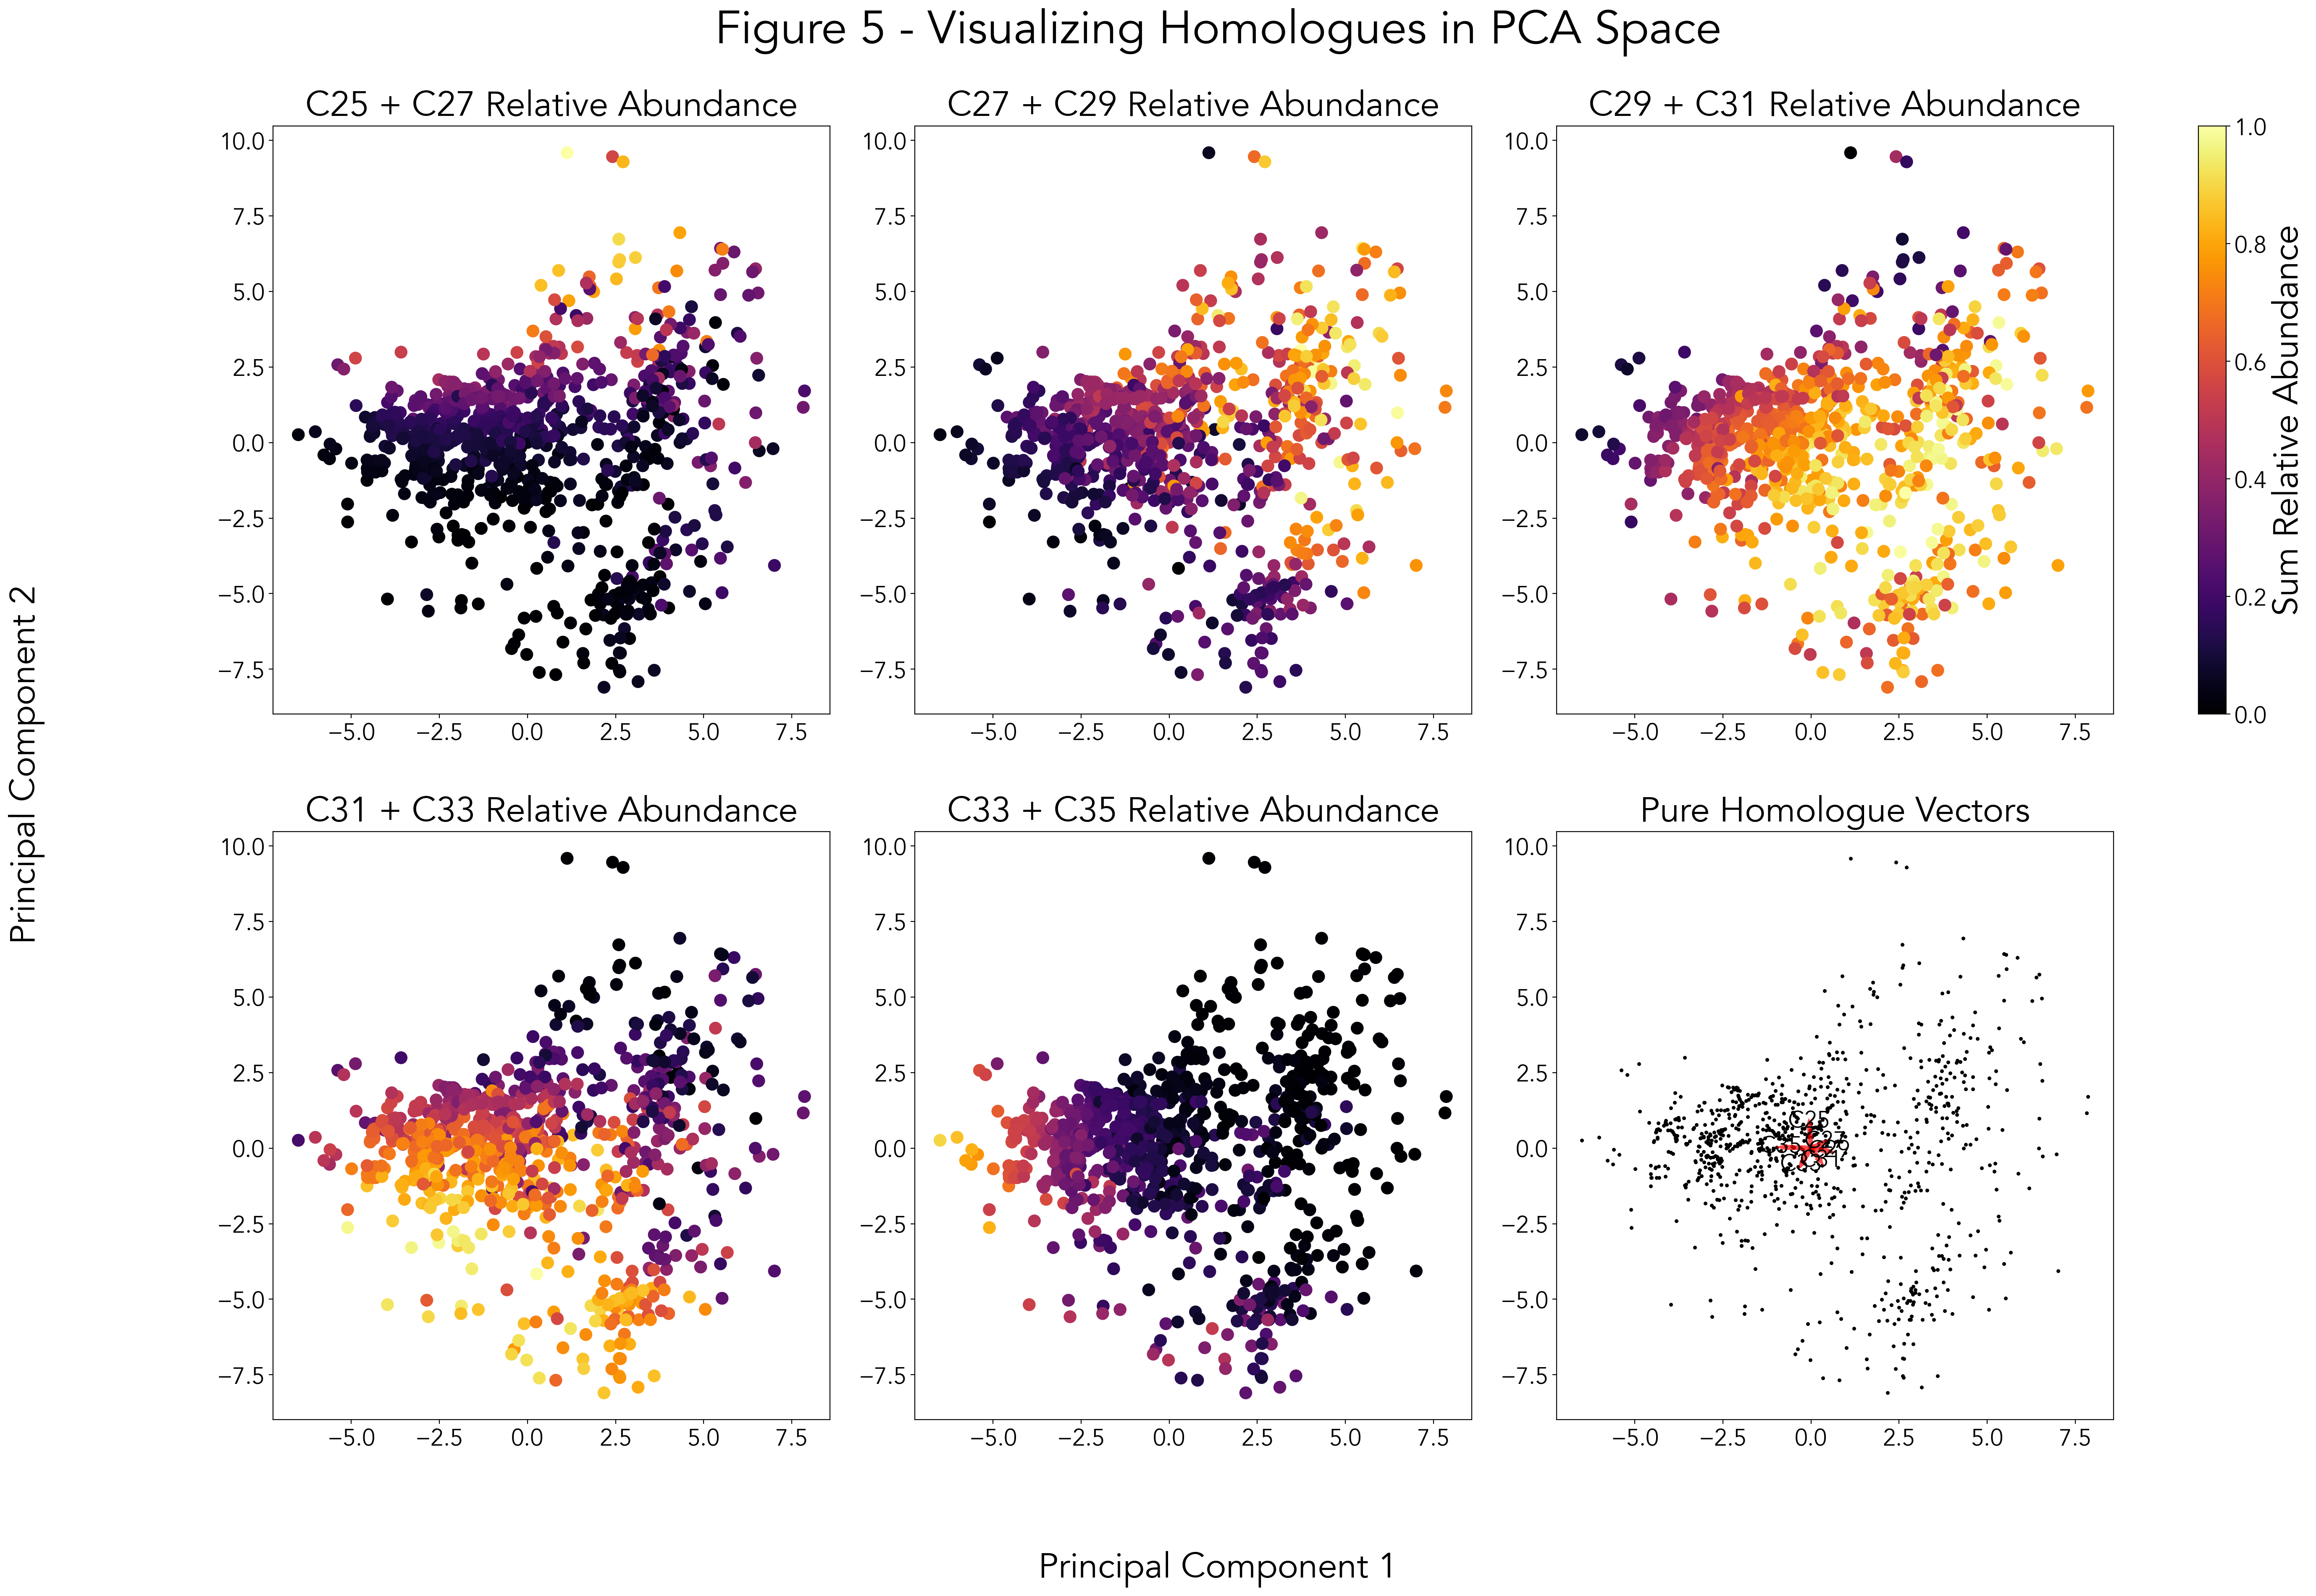

In [23]:
pca_sum_hom_influence(min_df, pca_df, pca_df.to_numpy()[:,0:2], pca_for_z.components_.T, labels=['C25', 'C27', 'C29', 'C31', 'C33', 'C35'])